In [28]:
import solver, validator
import file_manager as fm
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

importlib.reload(solver)
importlib.reload(validator)
importlib.reload(fm)

<module 'file_manager' from '/Users/reuter/Documents/Cambridge/SRIM/neural/file_manager.py'>

In [20]:
# dtype = torch.float64
# device = torch.device("cpu")
# theta_amp_initial = np.array([  3.72688684,  -8.66370198,  -4.52485751,  -3.63420301,
#          8.39016518,  22.0520419 ,  11.8855687 , -10.07123414,
#          6.31198641,  -6.44792308,  -6.88839233,  -5.39316903,
#         -3.53666167])


# theta_phase_initial = np.array([ 2.32026118e-02,  1.38276247e-02,  1.86365318e-02,  2.30379838e-02,
#        -5.27642228e-03, -1.16231611e-02,  3.99272956e+00,  6.67027706e+00,
#         9.32439296e+00,  1.18731508e+01, -6.83404835e-01, -2.55357464e+00,
#        -5.76320983e+00, -1.03325956e+01])
# eM_trial = 85
# theta_1 = torch.nn.Parameter(torch.as_tensor(theta_amp_initial, dtype=dtype,device=device).clone())
# theta_2 = torch.nn.Parameter(torch.as_tensor(theta_phase_initial, dtype=dtype,device=device).clone())

In [35]:
theta_1, theta_2, seed_info = fm.load_C1_seed("seeds/C1_seed_25_p4.npz", device="cpu", dtype=torch.float64)
print(seed_info)
eM_trial = 20

{'eM': 25.0, 'q': 1.0, 'lam': 0.0, 'm_over_e': 0.0, 'k': 1, 'p_amp': 4, 'p_phase': 4, 'loss': 9.735749066185889e-17, 'diagnostics': {'charge_residual': 1.026935203540802e-09, 'Re_Phi_U_1': -3.0960504357469e-07, 'Im_Phi_U_1': 2.212244352116366e-07, 'residual_norm': 3.8052146895741055e-07, 'max_residual': 3.0960504357469e-07, 'inf_xi': 0.004719468069397948, 'sup_rU': -0.07475840735890091, 'I_theta': 0.040000000041077406, 'phase_winding': 2.196466175656769, 'min_domega': -0.14679416264341683, 'max_domega': 4.533096318100231, 'min_r': 0.004719468069397948, 'rV_0': 3.269392429513165, 'rU_0': -0.07646680702604634, 'interpolated_min_focusing': 1.1391252562109193e-07, 'ode_nfev': 7532, 'ode_njev': 0, 'ode_nlu': 0, 'ode_message': 'The solver successfully reached the end of the integration interval.', 'matching_ok': True, 'xi_ok': True, 'rU_ok': True, 'finite': True, 'valid': True}}


In [36]:
coarse_n_grid = 1001
medium_n_grid = 2001
fine_n_grid = 4001
coarse_loss_tol = 1e-7
medium_loss_tol = 1e-11
fine_loss_tol = 1e-16

def objective_C1(n_grid):
    return solver.loss_C1(theta_1, theta_2, eM_trial, q=1, rho_drho_func=solver.tanh_ansatz, omega_domega_func=solver.omega_domega, n_grid=n_grid)

# profile_result = solver.profile_adam_step(
#     parameters=[theta_1, theta_2],
#     loss_fn=lambda: objective_C1(fine_n_grid),
#     lr=1e-3,
#     row_limit=25,
# )

In [38]:
print(f"Coarse stage: n_grid={coarse_n_grid}")
coarse_result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=lambda: objective_C1(coarse_n_grid),
    lr=1e-3,
    max_iter=500,
    loss_tol=coarse_loss_tol,
    grad_tol=1e-10,
    patience=200,
)

with torch.no_grad():
    theta_1.copy_(coarse_result["best_params"][0])
    theta_2.copy_(coarse_result["best_params"][1])
print(f"Medium stage: n_grid={medium_n_grid}")
medium_result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=lambda: objective_C1(medium_n_grid),
    lr=1e-3,  
    max_iter=800,
    loss_tol=medium_loss_tol,
    grad_tol=1e-10,
    patience=200,
)

with torch.no_grad():
    theta_1.copy_(medium_result["best_params"][0])
    theta_2.copy_(medium_result["best_params"][1])
    
print(f"Fine stage: n_grid={fine_n_grid}")
result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=lambda: objective_C1(fine_n_grid),
    lr=1e-3,
    max_iter=1000,
    loss_tol=fine_loss_tol,
    grad_tol=1e-10,
)

Coarse stage: n_grid=1001
Stopped at step 0: loss tolerance reached (8.847652e-10).
Medium stage: n_grid=2001
step=    0, loss=7.802952e-10, best=7.802952e-10, |g|=7.523512e-06
step=   20, loss=2.152240e-07, best=7.802952e-10, |g|=9.938989e-04
step=   40, loss=3.047250e-08, best=7.596392e-10, |g|=3.830751e-04
step=   60, loss=4.596013e-09, best=1.926639e-10, |g|=1.476738e-04
step=   80, loss=2.302785e-10, best=1.112906e-10, |g|=3.000796e-05
Stopped at step 98: loss tolerance reached (6.296122e-12).
Fine stage: n_grid=4001
step=    0, loss=2.515311e-12, best=2.515311e-12, |g|=2.352798e-06
step=   20, loss=7.642418e-07, best=2.515311e-12, |g|=1.963251e-03
step=   40, loss=4.688052e-09, best=2.515311e-12, |g|=1.514030e-04
step=   60, loss=7.347925e-10, best=2.515311e-12, |g|=5.978594e-05
step=   80, loss=1.545177e-09, best=2.515311e-12, |g|=8.834505e-05
step=  100, loss=7.734050e-12, best=1.813645e-13, |g|=6.153170e-06
step=  120, loss=5.998984e-12, best=1.813645e-13, |g|=5.508517e-06
ste

In [39]:
best_theta_1_torch, best_theta_2_torch = result["best_params"]

best_theta_1 = (best_theta_1_torch.detach().cpu().numpy())
best_theta_2 = (best_theta_2_torch.detach().cpu().numpy())

print("coarse best loss:", coarse_result["best_loss"])
print("coarse stop reason:", coarse_result["stop_reason"])
print("fine best loss:", result["best_loss"])
print("fine stop reason:", result["stop_reason"])

coarse best loss: 8.847651819177473e-10
coarse stop reason: loss tolerance reached
fine best loss: 8.764377923603278e-18
fine stop reason: loss tolerance reached


In [40]:
validation = validator.validate_C1(
    theta_amp=best_theta_1,
    theta_phase=best_theta_2,
    eM=eM_trial,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    k=1,
    rho_drho_func=solver.tanh_ansatz,
    omega_domega_func=solver.omega_domega,
    rplus_and_Qtarget_func=solver.rplus_and_Qtarget,
    ansatz_backend="torch",
    n_grid=10001,
    n_profile=10001,
    rtol=1e-11,
    atol=1e-13,
    max_step=2e-3,
    match_tol=1e-6,
    xi_margin=0.0,
    rU_margin=0.0,
)

C1 SCIPY VALIDATION: VALID

Matching residuals
  Q(1)-Q_target       = +2.286302258625e-09
  Re Phi_U(1)         = -1.432497858667e-07
  Im Phi_U(1)         = +2.912778866264e-07
  residual L2 norm    = 3.246051995369e-07
  largest residual    = 2.912778866264e-07

Admissibility
  inf xi              = +4.871573526073e-03
  sup r_U             = -7.296642105134e-02
  xi condition        = True
  r_U condition       = True

Phase
  omega(1)-omega(0)   = +2.769818321367e+00
  min omega'          = -3.932015433077e-01
  max omega'          = +5.744560870964e+00

Numerics
  grid points         = 10001
  profile points      = 10001
  DOP853 evaluations  = 7532
  interpolated min E  = +1.167172416694e-07
  matching tolerance  = 1.000e-06


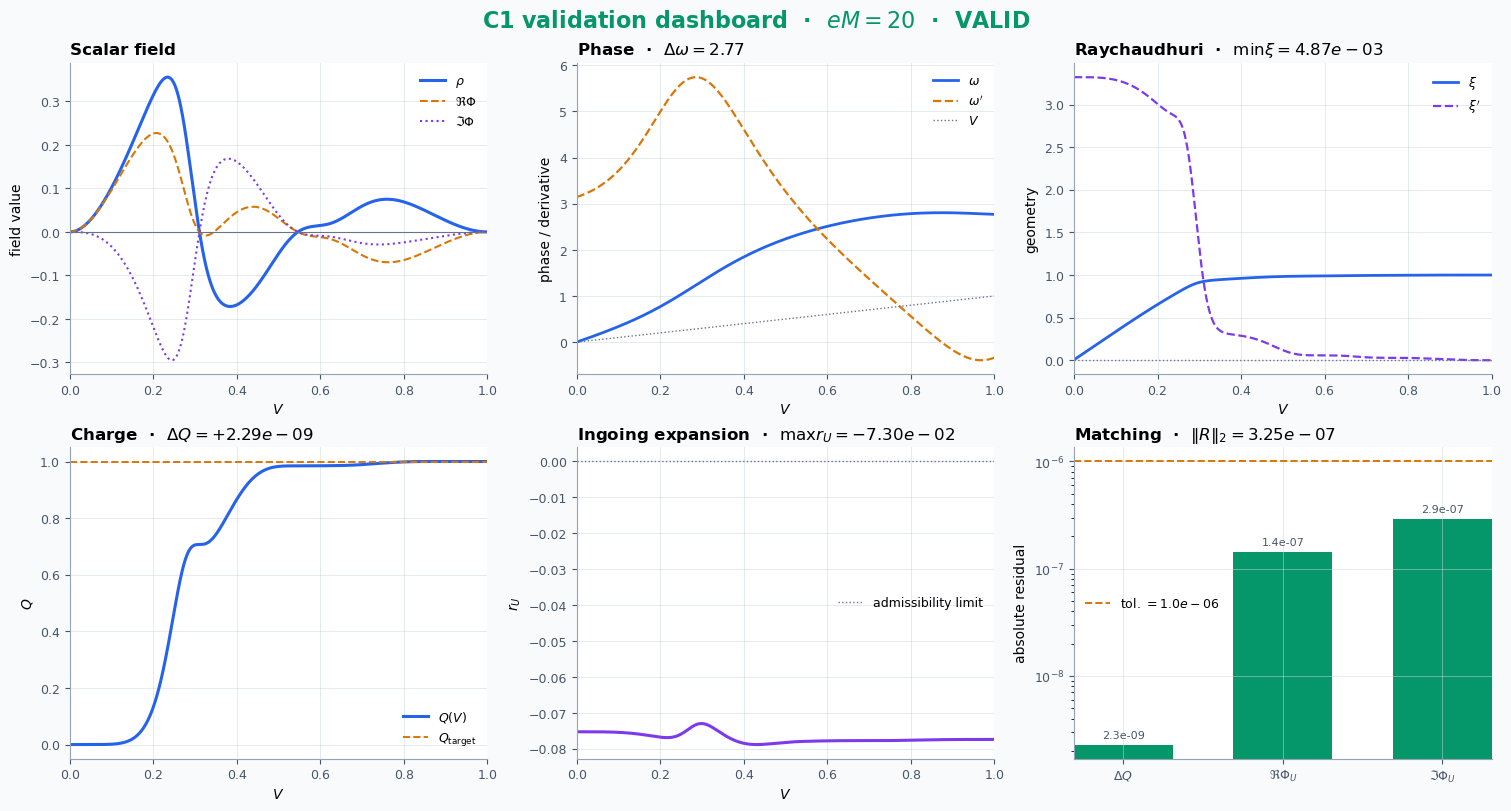

In [41]:
validator.print_C1_validation(validation)

dashboard_fig, dashboard_axes = validator.plot_C1_dashboard(validation)

In [42]:
fm.save_C1_seed(
    f"seeds/C1_seed_{eM_trial}_p4.npz",
    theta_amp=best_theta_1,
    theta_phase=best_theta_2,
    eM=eM_trial,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    k=1,
    loss=result["best_loss"],
    diagnostics=validation["diagnostics"],)

Saved seed to seeds/C1_seed_20_p4.npz
